<a href="https://colab.research.google.com/github/wtryab-re/machine-learning-reboost/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Libraries


In [ ]:
!pip install matplotlib seaborn numpy pandas scikit-learn

Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Read Dataset

In [10]:
df = pd.read_csv("titanic.csv")

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Dataset Information & Desc

In [8]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Pre imputation look at values

In [121]:
sns.set_style("darkgrid")

<Figure size 600x600 with 0 Axes>

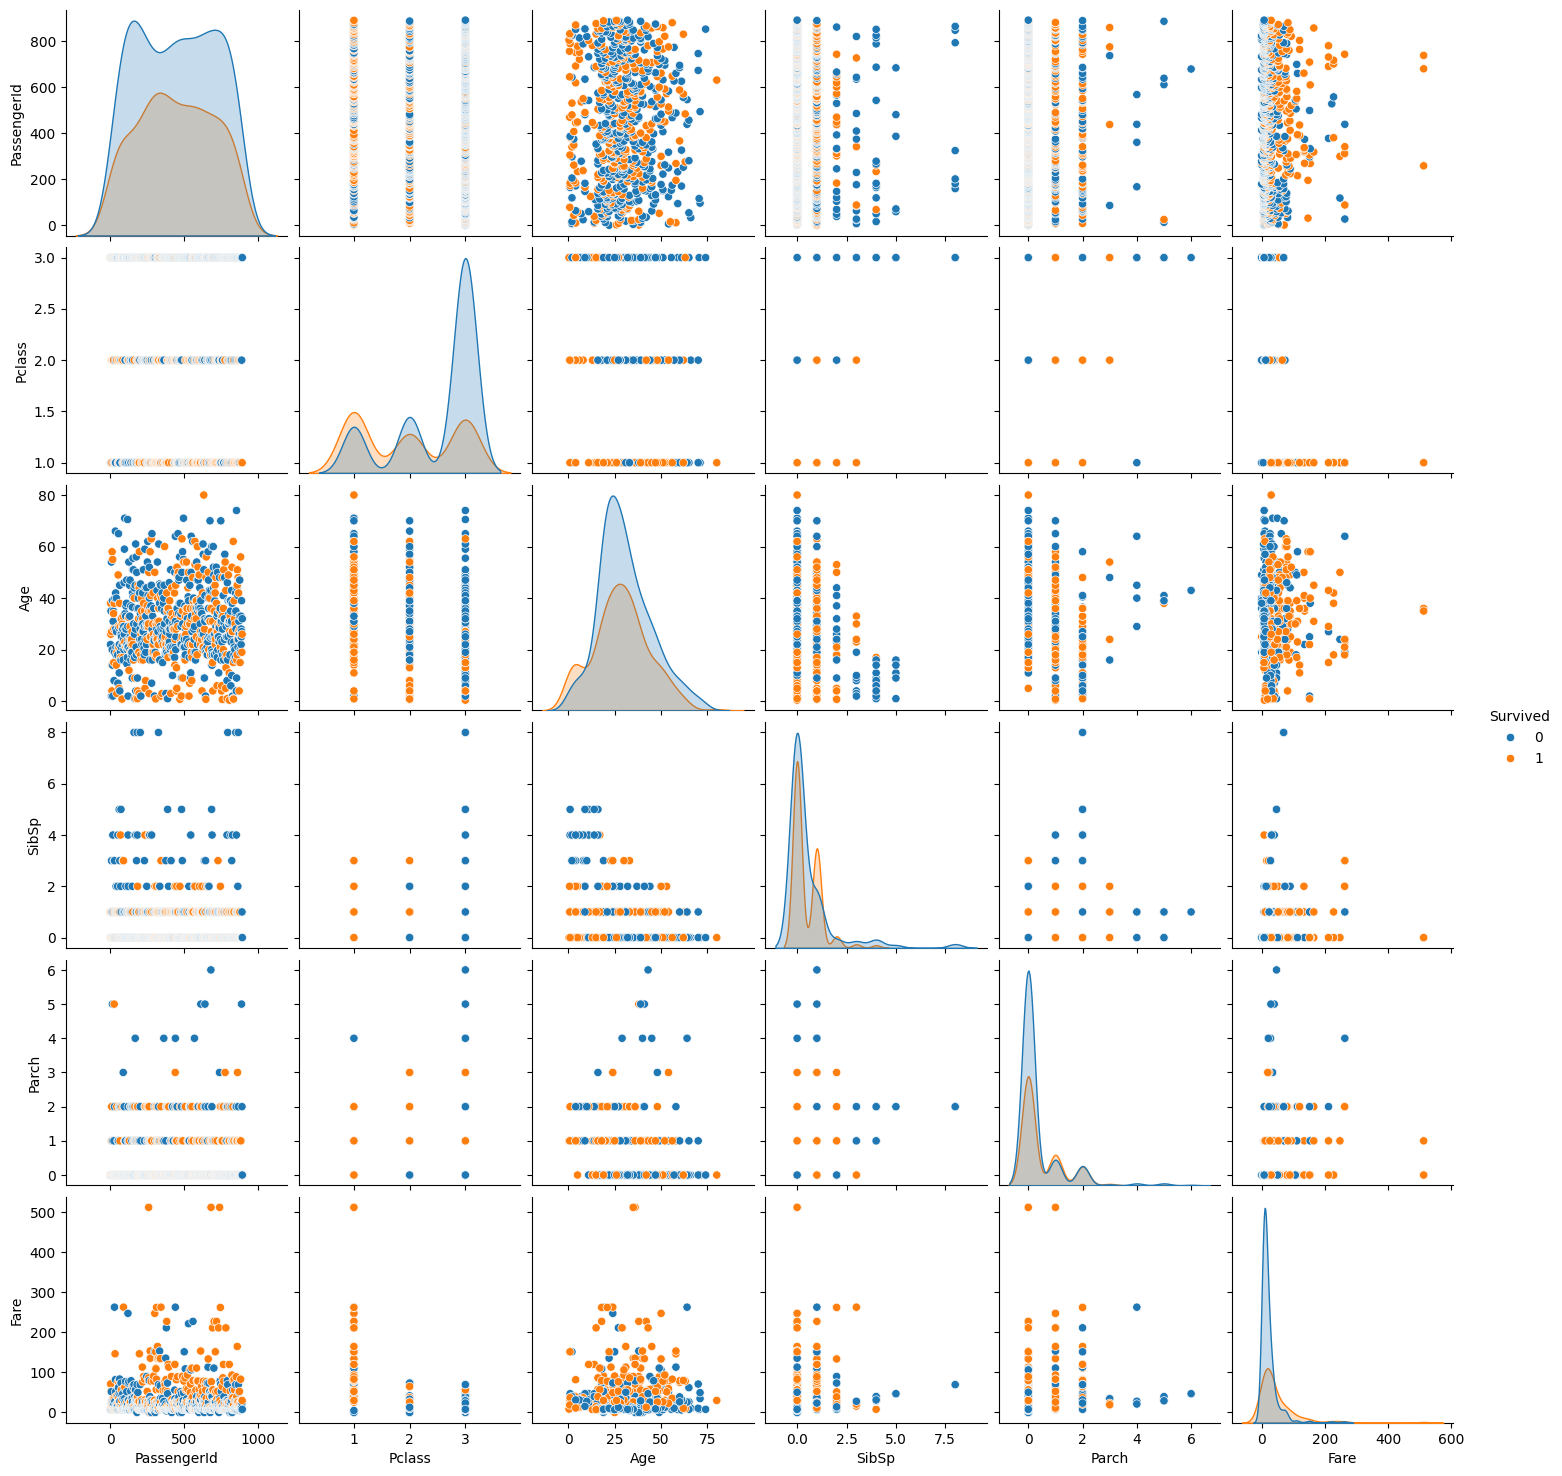

In [27]:
plt.figure(figsize=(6,6))
sns.pairplot(df, hue="Survived")

Missing Values Check

In [13]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
##for situations like this Cabin one we can just replace all the nan with Unknown.
df.fillna({"Cabin":"Unknown"}, inplace=True)

In [33]:
df["Cabin"].isna().sum()

np.int64(0)

In [36]:
##Age mean and median are almost the same so we can impute missing values with the Mean
df.fillna({"Age":df["Age"].mean()}, inplace=True)

In [40]:
df["Age"].isna().sum()

np.int64(0)

In [42]:
#Embarked is gonna be replaced with Unknown
df["Embarked"].unique()
df.fillna({"Embarked": "Unknown"},inplace=True)

In [43]:
df["Embarked"].isna().sum()

np.int64(0)

In [44]:
#Check
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#Analysis Time

In [48]:
survived_classes=["No","Yes"]
target=dict(enumerate(survived_classes))
df["Survived_T"] = df["Survived"].map(target)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived_T
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,No
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Yes
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Yes
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,No


In [50]:
x = df.drop(["Survived", "Survived_T"], axis=1)
y = df["Survived"]

Post Imputation Check

In [61]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [86]:
#Survived vs Not Survived
df["Survived_T"].value_counts()

,count
Survived_T,
No,549
Yes,342


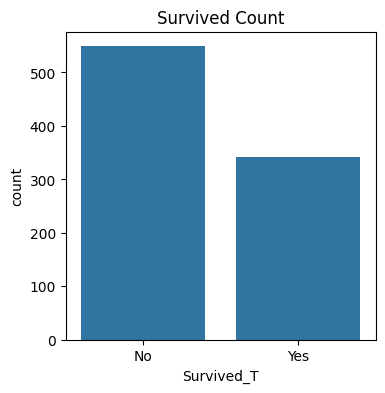

In [70]:
#Survived vs Not Survived
plt.figure(figsize=(4,4))
sns.countplot(x="Survived_T", data=df)
plt.title("Survived Count")
plt.show()

In [102]:
#Survival based on gender
df.groupby("Survived_T")["Sex"].value_counts()

Survived_T  Sex   
No          male      468
            female     81
Yes         female    233
            male      109
Name: count, dtype: int64

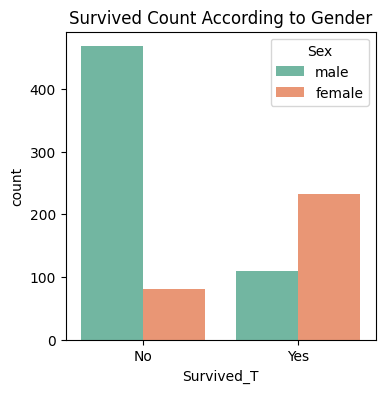

In [103]:
#Survived vs Not Survived Gender Analysis
plt.figure(figsize=(4,4))
sns.countplot(x="Survived_T", data=df, hue="Sex", palette="Set2")
plt.title("Survived Count According to Gender")
plt.show()

In [106]:
#Survival according to class
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [117]:
#Survival according to class
df.groupby("Survived_T")["Pclass"].value_counts()

Survived_T  Pclass
No          3         372
            2          97
            1          80
Yes         1         136
            3         119
            2          87
Name: count, dtype: int64

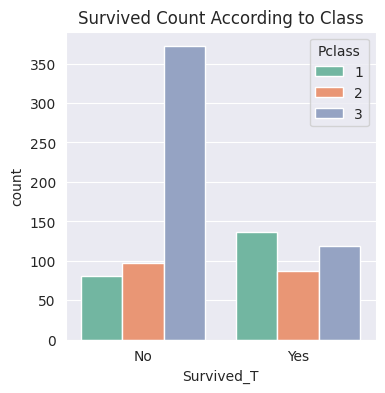

In [125]:
#Survival according to class
plt.figure(figsize=(4,4))
sns.countplot(
    x = "Survived_T", data=df, hue="Pclass", palette="Set2"
)
plt.title("Survived Count According to Class")
plt.show()

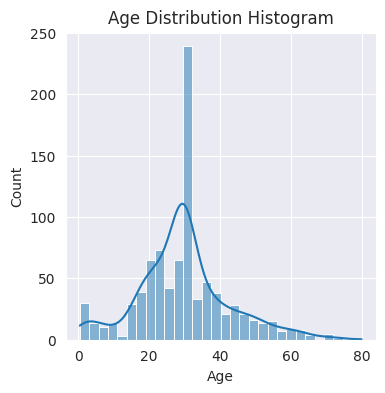

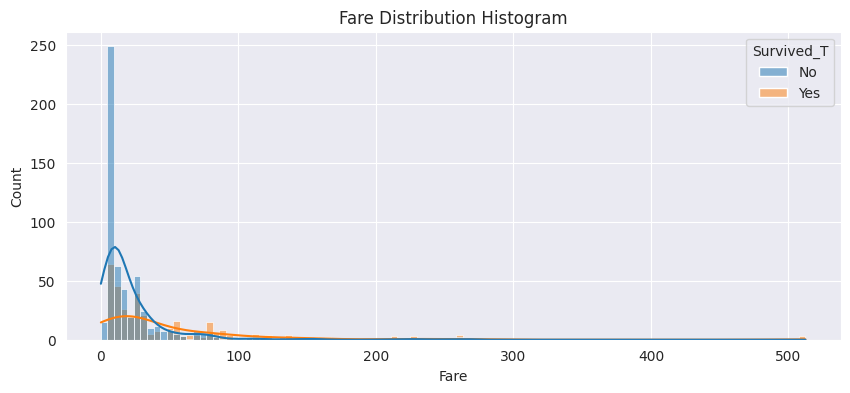

In [122]:
#Avg age and fare
df["Age"].mean()
df["Fare"].mean()

plt.figure(figsize=(4,4))
histogram = sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution Histogram")
plt.show()

plt.figure(figsize=(10,4))
histogram = sns.histplot(data=df, x="Fare", kde=True, hue="Survived_T")
plt.title("Fare Distribution Histogram")
plt.show()

#Additional


In [126]:
#Survival Rate accross age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [134]:
#Survival Count accross age groups
df.groupby("AgeGroup", observed=True)["Survived_T"].value_counts()

AgeGroup     Survived_T
Child        Yes            40
             No             29
Teen         No             40
             Yes            30
Young Adult  No            346
             Yes           189
Adult        No            117
             Yes            78
Senior       No             17
             Yes             5
Name: count, dtype: int64

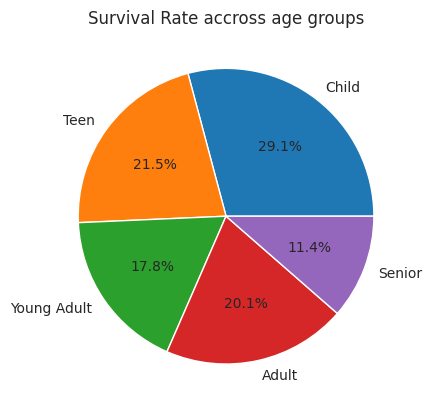

In [143]:
#Survival Rate accross age groups ... 1's and zeros so yeah i guess its a rate but i dont wanna use it
df.groupby("AgeGroup", observed=True)["Survived"].mean()

plt.pie(
    df.groupby("AgeGroup", observed=True)["Survived"].mean(),
    labels=df.groupby("AgeGroup", observed=True)["Survived"].mean().index,
    autopct="%1.1f%%"
)
plt.title("Survival Rate accross age groups")
plt.show()

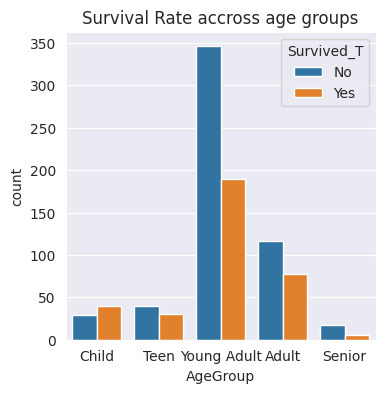

In [136]:
#Survival Count accross age groups
plt.figure(figsize=(4,4))
sns.countplot(x="AgeGroup", data=df, hue="Survived_T")
plt.title("Survival Rate accross age groups")
plt.show()

#Fare Distribution for survivors and non survivors

In [146]:
df.groupby("Survived_T")["Fare"].mean()

,Fare
Survived_T,
No,22.117887
Yes,48.395408


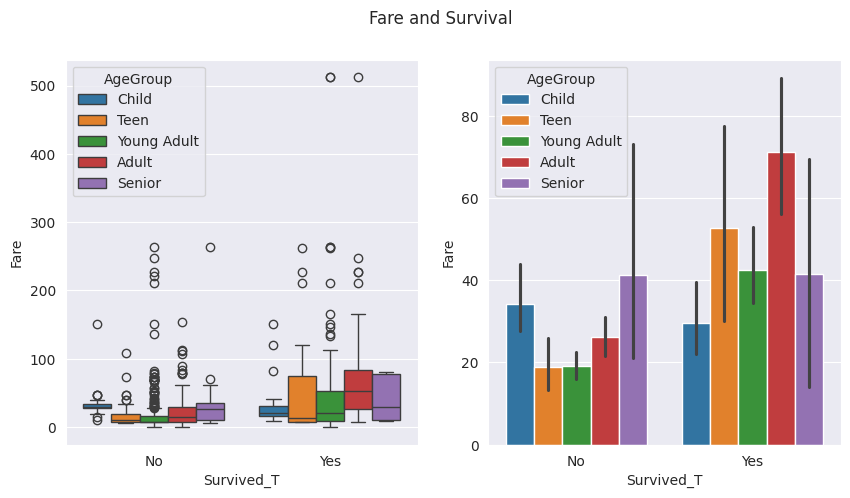

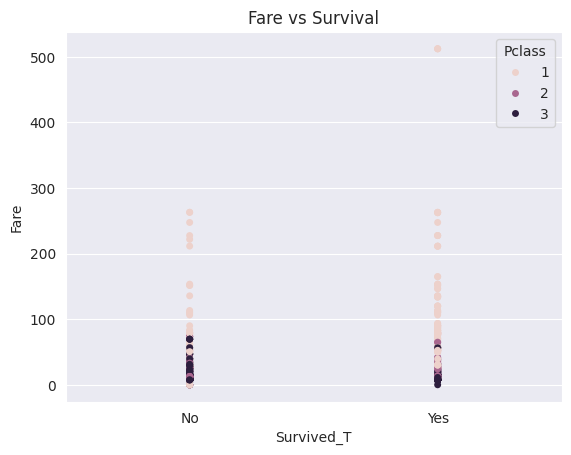

In [184]:
#Fare Distribution for survivors and non survivors
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(x="Survived_T", y="Fare", data=df, hue="AgeGroup")

plt.subplot(1,2,2)
sns.barplot(x="Survived_T", y="Fare", data=df, hue="AgeGroup")
plt.suptitle("Fare and Survival")
plt.show()

sns.stripplot(x="Survived_T", y="Fare",hue="Pclass",  data=df, jitter=False)
plt.title("Fare vs Survival")
plt.show()

#Heatmap

<Axes: >

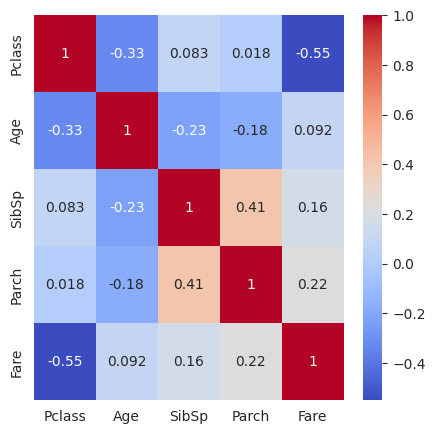

In [190]:
x.drop(columns="PassengerId", inplace=True)
correlation = x.corr(numeric_only=True)
plt.figure(figsize=(5,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm")